In [ ]:
import pandas as pd
import numpy as np
import time
a= time.time()
# exe time 26-28 second

# plan
1. Read the file, -- i need the col pos or names
2. clean the stipend
3. clear the q3 - q4 confusion
4. Achademic stat
5. working stat

In [ ]:
raw = pd.read_excel('/content/DS_SurveyJan26-check-auto.xlsx', sheet_name= 'check_auto')
raw.shape

(33408, 64)

In [ ]:
raw.columns = raw.columns.str.strip()

In [ ]:
raw.columns

Index(['email', 'student_email', 'Q1', 'Q1_1', 'Q1_1_1', 'Q1_1_2', 'Q1_2',
       'Q1_2_1_Q1_2_2', 'Q1_2_3_Q1_2_4', 'Q1_3', 'Q1_4', 'Q2', 'Q2_1_1',
       'Q2_1_2', 'Q2_1_3', 'Q2_1_4', 'Q2_1_5', 'Q2_1_6', 'Q3', 'Q3_1',
       'Q3_1_1', 'Q4', 'Q4_1', 'Q4_1_1', 'Q4_1_1_1', 'Q4_1_2', 'Q4_1_3',
       'Q4_1_4', 'Q4_1_5', 'Q4_1_6', 'Q4_2', 'Q4_2_1', 'Q4_2_2', 'Q4_2_4',
       'Q4_2_6', 'Q4_3', 'Q4_4', 'Q4_4_1', 'Q4_4_1_1', 'Q4_4_2', 'Q4_4_3',
       'Q4_5', 'Q5', 'Q5_1', 'Q5_1_1', 'Q5_1_2', 'Q5_1_3', 'Q5_2', 'Q5_2_1',
       'Q6_2', 'Q6_2_1_Q6_2_3', 'Q6_2_2', 'Q7_10', 'Q7_11', 'Q7_13', 'Q7_3',
       'Q7_5', 'Q7_6_Q7_9', 'Q7_8', 'gender', 'age', 'state', 'cgpa', 'level'],
      dtype='object')

In [ ]:
Q1= "Q1" # completed
Q1_LEVEL= "Q1_1_1"  # Q1 level
Q2= "Q2"  # enrolled other?
Q2_LEVEL="Q2_1_1" # Q2 level
Q3= "Q3" # employed?
Q3_SECTOR = "Q3_1_1" # employment sector
Q4= "Q4" # last term- new job/intenship
Q4_1_1_1= "Q4_1_1_1" # Paid internship
Q4_1_2= "Q4_1_2" # stiphend
Q4_2_2= "Q4_2_2" # salary
Q5= "Q5" # Admission Master/PHD
Q5_1= "Q5_1_2"  # country
Q5_1_1= "Q5_1_1"       # College name

In [ ]:
def low(row,col):
  return row[col].lower()

raw['gender'] = raw.apply(lambda row: low(row,'gender'), axis=1)

## cleaning Q3-Q4 conflicts
|Q3|Q4| |
|---|---|---|
|yes|no|
|yes|yes,_new_job|
|no|no|
|no|yes,_internship|

In [ ]:
raw.loc[raw[Q4] == "yes,_internship", Q3] = "no"
raw.loc[raw[Q4] == "yes,_new_job", Q3] = "yes"

## stipend clean

In [ ]:
import re

def clean_q4_1_2(val):
    if pd.isna(val):
        return ""

    if isinstance(val, (int, float)):
        return val

    s = str(val).strip().lower()

    # invalid cases
    if re.search(r"%|collection|na|nil|no", s):
        return ""

    # number + k
    if re.search(r"\d+\s*k", s):
        return int(re.search(r"\d+", s).group()) * 1000

    # number + usd
    if re.search(r"\d+.*usd", s):
        return int(re.search(r"\d+", s).group()) * 90

    # number + aed
    if re.search(r"\d+.*aed", s):
        return int(re.search(r"\d+", s).group()) * 24

    # fallback: extract digits (remove commas)
    match = re.search(r"[0-9,]+", s)
    if match:
        return int(match.group().replace(",", ""))

    return ""


In [ ]:
raw["Q4_1_2_stipend cleaned"] = raw[Q4_1_2].apply(clean_q4_1_2)

## academic str

In [ ]:
def ac_str(row):
  c= str(row[Q1])+ "-"+str(row[Q2])
  return c

raw['Q1-Q2 str join'] = raw.apply(ac_str, axis=1)

In [ ]:
def work_str(row):
  c= str(row[Q3])+ "-"+str(row[Q4])
  return c
raw['Q3-Q4 str join'] = raw.apply(work_str, axis=1)

In [ ]:
def ac_stat(row):
  if row['Q1-Q2 str join'] == 'yes-yes':
    return "ThirdDegree"
  elif row['Q1-Q2 str join'] == 'yes-no':
    return "HoldingDegree"
  elif row['Q1-Q2 str join'] == 'no-yes':
    return "DualDegree"
  elif row['Q1-Q2 str join'] == 'no-no':
    return "StandAlone"
  else:
    "#N/A"

raw['Degree Stat'] = raw.apply(ac_stat, axis=1)

In [ ]:
def work_stat(row):
  if row['Q3-Q4 str join']== 'yes-yes,_new_job':
    return "Taken New Job"
  elif row['Q3-Q4 str join']== 'yes-no':
    return "Already Working"
  elif row['Q3-Q4 str join']== 'no-yes,_internship':
    return "Under Internship"
  elif row['Q3-Q4 str join']== 'no-no':
    return "Not Working"
  else:
    "#N/A"

raw['Working Stat'] = raw.apply(work_stat, axis=1)

In [ ]:
raw['overall']= raw['Degree Stat']+' Students '+raw['Working Stat']

In [ ]:
raw.head()

,email,student_email,Q1,Q1_1,Q1_1_1,Q1_1_2,Q1_2,Q1_2_1_Q1_2_2,Q1_2_3_Q1_2_4,Q1_3,...,age,state,cgpa,level,Q4_1_2_stipend cleaned,Q1-Q2 str join,Q3-Q4 str join,Degree Stat,Working Stat,overall
0,kingdevansh123@gmail.com,22f1001032@ds.study.iitm.ac.in,yes,pg,ug,engineering,india,NaN,maharashtra,engineering,...,24,Assam,6.140845,DIPLOMA,25000,yes-yes,"no-yes,_internship",ThirdDegree,Under Internship,ThirdDegree Students Under Internship
1,devj6061@gmail.com,21f1000466@ds.study.iitm.ac.in,yes,pg,ug,engineering,india,NaN,west_bengal,engineering,...,21,Rajasthan,7.666667,DIPLOMA,,yes-yes,no-no,ThirdDegree,Not Working,ThirdDegree Students Not Working
2,aryanjbagwe@gmail.com,22f2000761@ds.study.iitm.ac.in,yes,pg,ug,sciences,india,NaN,maharashtra,sciences,...,20,Uttar-Pradesh,5.8,FOUNDATION,0,yes-yes,"no-yes,_internship",ThirdDegree,Under Internship,ThirdDegree Students Under Internship
3,ashumaurya9201@gmail.com,22f1001595@ds.study.iitm.ac.in,yes,pg,ug,engineering,india,NaN,rajasthan,engineering,...,18,Telangana,5.857143,FOUNDATION,25000,yes-yes,"no-yes,_internship",ThirdDegree,Under Internship,ThirdDegree Students Under Internship
4,balivadasricharitha05@gmail.com,21f2000491@ds.study.iitm.ac.in,yes,pg,ug,engineering,india,NaN,delhi,engineering,...,17,Tamil-Nadu,5.5,FOUNDATION,,yes-yes,"yes-yes,_new_job",ThirdDegree,Taken New Job,ThirdDegree Students Taken New Job


## report making

### vars

In [ ]:
BIN_OPTIONS=["yes","no"]
LEVEL_OPTIONS=[
    "ug",
    "pg",
    "phd",
    "not_available"
]
Q3_YES_OPTIONS=["yes,_new_job","no"]
Q3_NO_OPTIONS=["yes,_internship","no"]
SECTOR_OPTIONS=[
    "it", "finance", "consulting", "education", "engineering", "health_&_related",
    "entrepreneur", "sales_&_marketing", "government", "law", "others", "NOT_AVAILABLE"
]
STIPEND_RANGES = {
    "1–10000": (1, 10_000),
    "10001–20000": (10_001, 20_000),
    "20001–30000": (20_001, 30_000),
    "30001–40000": (30_001, 40_000),
    "40001–50000": (40_001, 50_000),
    "50001–60000": (50_001, 60_000),
    "60001–70000": (60_001, 70_000),
    "70001–80000": (70_001, 80_000),
    "80001–90000": (80_001, 90_000),
    "90001–1L":   (90_001, 100_000),
    "1L+":        (100_001, np.inf),
}
SALARY_SLABS = [
    "<3 LPA",
    "3–5 LPA",
    "5–10 LPA",
    "10–15 LPA",
    "15–20 LPA",
    "20–25 LPA",
    "25–50 LPA",
    "50+ LPA",
    "not_available"
]
DEGREE_OPTIONS = [
    "StandAlone",
    "DualDegree",
    "HoldingDegree",
    "ThirdDegree"
]
WORK_OPTIONS = [
    "Already Working",
    "Taken New Job",
    "Under Internship",
    "Not Working"
]
GENDER_OPTIONS = [
    "male",
    "female",
    "other"
]
MASTER_OPTIONS=[
    "yes",
    "applied_and_waiting_for_results",
    "no"
]
MASTER_ACC_OPTIONS= ["yes","applied_and_waiting_for_results"]
# MASTER_LOC_OPTIONS= ["yes", "applied_and_waiting_for_results"]
MASTER_LOC_OPTIONS= ["india", "outside_india", "not_specified"]
LEVEL_MAP = {
    "BS_DEGREE": "BS_DEGREE",
    "DEGREE": "DEGREE",
    "DIPLOMA": "DIPLOMA",
    "FOUNDATION": "FOUNDATION",
    "QUALIFIER": "FOUNDATION"
}


In [ ]:
def total_add_func(table_name_df):
  total_val = table_name_df["Jan26"].sum()
  table_name_df["%Jan26"] = (table_name_df["Jan26"] / total_val).round(5)
  total_percent= table_name_df["%Jan26"].sum()

  total_row_df = pd.DataFrame({
      table_name_df.columns[0]: ["Total"], # Corrected: use column name as string
      "Jan26": [total_val],
      "%Jan26": [total_percent]
  })

  return pd.concat([table_name_df, total_row_df], ignore_index=True)

### Q1-Q2

In [ ]:
Q1_DIST_TABLE =(raw.groupby(Q1)
    .size().reindex(BIN_OPTIONS,fill_value=0)
    .reset_index(name="count")
    .rename(columns={
        Q1:'Q1: completed other degree?',
        "count": "Jan26"
        })
)
Q1_DIST_TABLE= total_add_func(Q1_DIST_TABLE)
Q1_DIST_TABLE

,Q1: completed other degree?,Jan26,%Jan26
0,yes,5359,0.16041
1,no,28049,0.83959
2,Total,33408,1.00000


In [ ]:
Q1_LEVELS_TABLE= (
    raw[raw[Q1] == "yes"]
        .value_counts(Q1_LEVEL)
        .reindex(LEVEL_OPTIONS, fill_value=0)
        .reset_index()
        .rename(columns={
            Q1_LEVEL: "completed level",
            "count": "Jan26"})
)
Q1_LEVELS_TABLE= total_add_func(Q1_LEVELS_TABLE)
Q1_LEVELS_TABLE

,completed level,Jan26,%Jan26
0,ug,4126,0.77280
1,pg,1151,0.21558
2,phd,62,0.01161
3,not_available,0,0.00000
4,Total,5339,0.99999


In [ ]:
Q1_NO_TABLE = (
    raw[raw[Q1] == "no"]
        .groupby(Q2)
        .size()
        .reindex(BIN_OPTIONS, fill_value=0)
        .reset_index(name="Jan26")
        .rename(columns={
            Q2: "Q1_No number of standalones"})
)
Q1_NO_TABLE = total_add_func(Q1_NO_TABLE)
Q1_NO_TABLE

,Q1_No number of standalones,Jan26,%Jan26
0,yes,17295,0.6166
1,no,10754,0.3834
2,Total,28049,1.0000


In [ ]:
Q1_NO_YES_TABLE = (
    raw[(raw[Q1] == "no") & (raw[Q2] == "yes")]
        .groupby(Q2_LEVEL)
        .size()
        .reindex(LEVEL_OPTIONS, fill_value=0)
        .reset_index(name="Jan26")
        .rename(columns={Q2_LEVEL: "Q1_No_Yes dual student levels"})
)
Q1_NO_YES_TABLE = total_add_func(Q1_NO_YES_TABLE)
Q1_NO_YES_TABLE

,Q1_No_Yes dual student levels,Jan26,%Jan26
0,ug,17082,0.98992
1,pg,168,0.00974
2,phd,6,0.00035
3,not_available,0,0.00000
4,Total,17256,1.00001


### employed Q3

In [ ]:
Q3_EMPLOYED_TABLE= raw.groupby(Q3).size().reindex(BIN_OPTIONS,fill_value=0).reset_index(name="Jan26").rename(columns={Q3:'Q3: employed?'})
Q3_EMPLOYED_TABLE= total_add_func(Q3_EMPLOYED_TABLE)
Q3_EMPLOYED_TABLE

,Q3: employed?,Jan26,%Jan26
0,yes,3503,0.10486
1,no,29905,0.89514
2,Total,33408,1.00000


In [ ]:
Q3_YES_TABLE = (
    raw[(raw[Q3] == "yes")]
        .groupby(Q4)
        .size()
        .reindex(Q3_YES_OPTIONS, fill_value=0)
        .reset_index(name="Jan26")
        .rename(columns={Q4: "Q3_yes employed status"})
)
Q3_YES_TABLE = total_add_func(Q3_YES_TABLE)
Q3_YES_TABLE

,Q3_yes employed status,Jan26,%Jan26
0,"yes,_new_job",379,0.10819
1,no,3124,0.89181
2,Total,3503,1.00000


In [ ]:
Q3_NO_TABLE = (
    raw[(raw[Q3] == "no")]
        .groupby(Q4)
        .size()
        .reindex(Q3_NO_OPTIONS, fill_value=0)
        .reset_index(name="Jan26")
        .rename(columns={Q4: "Q3_no employment status"})
)
Q3_NO_TABLE = total_add_func(Q3_NO_TABLE)
Q3_NO_TABLE

,Q3_no employment status,Jan26,%Jan26
0,"yes,_internship",1115,0.03728
1,no,28790,0.96272
2,Total,29905,1.00000


In [ ]:
Q3_SECTOR_TABLE = (
    raw[(raw[Q3] == "yes")]
        .groupby(Q3_SECTOR)
        .size()
        .reindex(SECTOR_OPTIONS, fill_value=0)
        .reset_index(name="Jan26")
        .rename(columns={Q3_SECTOR: "employed status"})
)
Q3_SECTOR_TABLE = total_add_func(Q3_SECTOR_TABLE)

Q3_SECTOR_TABLE

,employed status,Jan26,%Jan26
0,it,1573,0.44904
1,finance,158,0.04510
2,consulting,125,0.03568
3,education,213,0.06081
4,engineering,510,0.14559
5,health_&_related,91,0.02598
6,entrepreneur,106,0.03026
7,sales_&_marketing,106,0.03026
8,government,208,0.05938
9,law,5,0.00143


In [ ]:
PAID_INTERNSHIP_TABLE= (
    raw[(raw[Q4] == "yes,_internship")]
        .groupby(Q4_1_1_1)
        .size()
        .reindex(BIN_OPTIONS, fill_value=0)
        .reset_index(name="Jan26")
        .rename(columns={Q4_1_1_1: "is it paid internship"})
)
PAID_INTERNSHIP_TABLE= total_add_func(PAID_INTERNSHIP_TABLE)
PAID_INTERNSHIP_TABLE

,is it paid internship,Jan26,%Jan26
0,yes,623,0.5638
1,no,482,0.4362
2,Total,1105,1.0000


### stipend

In [ ]:
def stipend_range_counts(df, col):
    """
    Returns a dict: {range_label: count}
    Blank / NaN values are counted as 'not_available'
    """

    counts = {k: 0 for k in STIPEND_RANGES}
    counts["not_available"] = 0

    for val in df[col]:
        if pd.isna(val) or val == "":
            counts["not_available"] += 1
            continue

        try:
            v = float(val)
        except:
            counts["not_available"] += 1
            continue

        matched = False
        for label, (low, high) in STIPEND_RANGES.items():
            if low <= v <= high:
                counts[label] += 1
                matched = True
                break

        if not matched:
            counts["not_available"] += 1

    return counts


In [ ]:
def stipend_dict_to_table(d):
    return (
        pd.DataFrame(list(d.items()), columns=["range", "Jan26"])
    )

In [ ]:
stipend_dict = stipend_range_counts(raw[(raw[Q4]=='yes,_internship') & (raw[Q4_1_1_1]=='yes')], "Q4_1_2_stipend cleaned")
STIPEND_TABLE = stipend_dict_to_table(stipend_dict)
STIPEND_TABLE = total_add_func(STIPEND_TABLE)

In [ ]:
STIPEND_TABLE

,range,Jan26,%Jan26
0,1–10000,194,0.31140
1,10001–20000,159,0.25522
2,20001–30000,95,0.15249
3,30001–40000,32,0.05136
4,40001–50000,29,0.04655
5,50001–60000,4,0.00642
6,60001–70000,4,0.00642
7,70001–80000,7,0.01124
8,80001–90000,4,0.00642
9,90001–1L,6,0.00963


### salary

In [ ]:
import pandas as pd

def map_salary_slab_text(val):
    if pd.isna(val) or str(val).strip() == "":
        return "not_available"
    s = str(val).lower().replace(" ", "").replace("_", "")

    if s.startswith("<3"):
        return "<3 LPA"

    if "3" in s and "5" in s:
        return "3–5 LPA"

    if "5" in s and "10" in s:
        return "5–10 LPA"

    if "10" in s and "15" in s:
        return "10–15 LPA"

    if "15" in s and "20" in s:
        return "15–20 LPA"

    if "20" in s and "25" in s:
        return "20–25 LPA"

    # collapsing slabs
    if any(x in s for x in ["25", "30", "35", "40", "45", "50"]) and "+" not in s:
        return "25–50 LPA"

    if "+" in s or s.startswith("50"):
        return "50+ LPA"

    return "not_available"


In [ ]:
dummy= raw[raw[Q4]=="yes,_new_job"].copy()
dummy["salary_slab"] = dummy[Q4_2_2].apply(map_salary_slab_text)

In [ ]:
dummy

,email,student_email,Q1,Q1_1,Q1_1_1,Q1_1_2,Q1_2,Q1_2_1_Q1_2_2,Q1_2_3_Q1_2_4,Q1_3,...,state,cgpa,level,Q4_1_2_stipend cleaned,Q1-Q2 str join,Q3-Q4 str join,Degree Stat,Working Stat,overall,salary_slab
4,balivadasricharitha05@gmail.com,21f2000491@ds.study.iitm.ac.in,yes,pg,ug,engineering,india,NaN,delhi,engineering,...,Tamil-Nadu,5.5,FOUNDATION,,yes-yes,"yes-yes,_new_job",ThirdDegree,Taken New Job,ThirdDegree Students Taken New Job,5–10 LPA
13,vedantsawant72003@gmail.com,23f1002365@ds.study.iitm.ac.in,yes,pg,ug,engineering,outside_india,Stuttgart,NaN,engineering,...,Telangana,7.290909,DEGREE,,yes-yes,"yes-yes,_new_job",ThirdDegree,Taken New Job,ThirdDegree Students Taken New Job,3–5 LPA
16,dhivyalakshmyraman@gmail.com,25f3005576@ds.study.iitm.ac.in,yes,pg,pg,engineering,india,NaN,tamil_nadu,engineering,...,West-Bengal,8.146154,BS_DEGREE,,yes-yes,"yes-yes,_new_job",ThirdDegree,Taken New Job,ThirdDegree Students Taken New Job,5–10 LPA
22,palanish12@gmail.com,22f1001091@ds.study.iitm.ac.in,yes,pg,ug,engineering,india,NaN,maharashtra,engineering,...,West-Bengal,9.315789,DIPLOMA,,yes-yes,"yes-yes,_new_job",ThirdDegree,Taken New Job,ThirdDegree Students Taken New Job,5–10 LPA
24,profsimranjeetsingh@gmail.com,21f1001268@ds.study.iitm.ac.in,yes,pg,ug,others,india,NaN,chandigarh,others,...,Maharashtra,6.646341,DIPLOMA,,yes-yes,"yes-yes,_new_job",ThirdDegree,Taken New Job,ThirdDegree Students Taken New Job,5–10 LPA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23271,hameessayed71@gmail.com,23f1001168@ds.study.iitm.ac.in,no,NOT_AVAILABLE,NOT_AVAILABLE,NaN,NOT_AVAILABLE,NaN,NaN,NaN,...,Maharashtra,8.007937,BS_DEGREE,,no-no,"yes-yes,_new_job",StandAlone,Taken New Job,StandAlone Students Taken New Job,not_available
29025,nidhishar1@gmail.com,23f2003851@ds.study.iitm.ac.in,no,NOT_AVAILABLE,NOT_AVAILABLE,NaN,NOT_AVAILABLE,NaN,NaN,NaN,...,Rajasthan,6.965517,DIPLOMA,,no-no,"yes-yes,_new_job",StandAlone,Taken New Job,StandAlone Students Taken New Job,not_available
30091,rajkumarsingh56218@gmail.com,25f2007751@ds.study.iitm.ac.in,no,NOT_AVAILABLE,NOT_AVAILABLE,NaN,NOT_AVAILABLE,NaN,NaN,NaN,...,Uttar-Pradesh,6.571429,FOUNDATION,,no-no,"yes-yes,_new_job",StandAlone,Taken New Job,StandAlone Students Taken New Job,not_available
30802,saicharitha2006@gmail.com,24f2009184@ds.study.iitm.ac.in,no,ug,NOT_AVAILABLE,NaN,india,NaN,NaN,NaN,...,Karnataka,6.555556,DIPLOMA,,no-yes,"yes-yes,_new_job",DualDegree,Taken New Job,DualDegree Students Taken New Job,not_available


In [ ]:
SALARY_TABLE = (
    dummy["salary_slab"]
    .value_counts()
    .reindex(SALARY_SLABS, fill_value=0)
    .reset_index()
    .rename(columns={
        "count": "Jan26"
    })
)
SALARY_TABLE = total_add_func(SALARY_TABLE)
SALARY_TABLE

,salary_slab,Jan26,%Jan26
0,<3 LPA,50,0.13193
1,3–5 LPA,116,0.30607
2,5–10 LPA,143,0.37731
3,10–15 LPA,0,0.00000
4,15–20 LPA,14,0.03694
5,20–25 LPA,14,0.03694
6,25–50 LPA,5,0.01319
7,50+ LPA,0,0.00000
8,not_available,37,0.09763
9,Total,379,1.00001


### master

In [ ]:
MASTER_DEGREE_TABLE= (
    raw[Q5]
    .value_counts()
    .reindex(MASTER_OPTIONS, fill_value=0)
    .reset_index()
    .rename(columns={
        "index": "index",
        Q5: "got masters/phd?",
        "count": "Jan26"
    })
)
MASTER_DEGREE_TABLE= total_add_func(MASTER_DEGREE_TABLE)
MASTER_DEGREE_TABLE

,got masters/phd?,Jan26,%Jan26
0,yes,465,0.01392
1,applied_and_waiting_for_results,206,0.00617
2,no,32737,0.97991
3,Total,33408,1.00000


In [ ]:
MASTER_ACC_DEGREE_TABLE= (
    raw[Q5]
    .value_counts()
    .reindex(MASTER_ACC_OPTIONS, fill_value=0)
    .reset_index()
    .rename(columns={
        "index": "index",
        Q5: "got masters/phd?",
        "count": "Jan26"
    })
)
MASTER_ACC_DEGREE_TABLE= total_add_func(MASTER_ACC_DEGREE_TABLE)
MASTER_ACC_DEGREE_TABLE

,got masters/phd?,Jan26,%Jan26
0,yes,465,0.693
1,applied_and_waiting_for_results,206,0.307
2,Total,671,1.000


### working, degree, big table

In [ ]:
DEGREE_STAT_TABLE = (
    raw["Degree Stat"]
    .value_counts()
    .reindex(DEGREE_OPTIONS, fill_value=0)
    .reset_index()
    .rename(columns={
        "index": "Degree Stat",
        "count": "Jan26"
    })
)
DEGREE_STAT_TABLE = total_add_func(DEGREE_STAT_TABLE)
DEGREE_STAT_TABLE

,Degree Stat,Jan26,%Jan26
0,StandAlone,10754,0.32190
1,DualDegree,17295,0.51769
2,HoldingDegree,4567,0.13670
3,ThirdDegree,792,0.02371
4,Total,33408,1.00000


In [ ]:
WORK_STAT_TABLE = (
    raw["Working Stat"]
    .value_counts()
    .reindex(WORK_OPTIONS, fill_value=0)
    .reset_index()
    .rename(columns={
        "index": "Working Stat",
        "count": "Jan26"
    })
)
WORK_STAT_TABLE = total_add_func(WORK_STAT_TABLE)
WORK_STAT_TABLE

,Working Stat,Jan26,%Jan26
0,Already Working,3124,0.09351
1,Taken New Job,379,0.01134
2,Under Internship,1115,0.03338
3,Not Working,28790,0.86177
4,Total,33408,1.00000


In [ ]:
# group normally
counts = (
    raw
    .groupby(["Degree Stat", "Working Stat",])
    .size()
)

# combination index
full_index = pd.MultiIndex.from_product(
    [DEGREE_OPTIONS, WORK_OPTIONS],
    names=["Degree Stat", "Working Stat"]
)

# reindex
BIG_TABLE = (
    counts
    .reindex(full_index, fill_value=0)
    .reset_index(name="Jan26")
)



In [ ]:
BIG_TABLE.sort_values(by=['Working Stat'],inplace=True)   # 'Degree Stat'

In [ ]:
BIG_TABLE= total_add_func(BIG_TABLE)

In [ ]:
BIG_TABLE

,Degree Stat,Working Stat,Jan26,%Jan26
0,StandAlone,Already Working,860,0.02574
1,DualDegree,Already Working,141,0.00422
2,HoldingDegree,Already Working,2053,0.06145
3,ThirdDegree,Already Working,70,0.00210
4,StandAlone,Not Working,9635,0.28840
5,DualDegree,Not Working,16450,0.49240
6,HoldingDegree,Not Working,2054,0.06148
7,ThirdDegree,Not Working,651,0.01949
8,StandAlone,Taken New Job,77,0.00230
9,DualDegree,Taken New Job,22,0.00066


### age, gender

In [ ]:
bins = [0, 19, 25, 30, 40, 50, 60, np.inf]
labels = ["<20", "20-25", "26-30", "31-40", "41-50", "51-60", "60+"]
AGE_TABLE = (
    pd.cut(pd.to_numeric(raw["age"], errors='coerce'), bins=bins, labels=labels, right=True)
    .value_counts(sort=False)
    .reset_index()
    .rename(columns={
        "index": "age_range",
        "count": "Jan26"
    })
)
AGE_TABLE = total_add_func(AGE_TABLE)
AGE_TABLE

,age,Jan26,%Jan26
0,<20,13808,0.41331
1,20-25,16317,0.48842
2,26-30,1295,0.03876
3,31-40,1216,0.03640
4,41-50,581,0.01739
5,51-60,163,0.00488
6,60+,28,0.00084
7,Total,33408,1.00000


In [ ]:
GENDER_TABLE= (
    raw['gender']
    .value_counts()
    .reindex(GENDER_OPTIONS, fill_value=0)
    .reset_index()
    .rename(columns={
        "index": "index",
        "count": "Jan26"
    })
)
GENDER_TABLE = total_add_func(GENDER_TABLE)
GENDER_TABLE

,gender,Jan26,%Jan26
0,male,23925,0.71615
1,female,9481,0.28379
2,other,2,0.00006
3,Total,33408,1.00000


### level-cgpa

In [ ]:
raw["level_std"] = raw["level"].map(LEVEL_MAP)

cgpa_bins = [-np.inf, 4, 5, 6, 7, 8, 9, 10]
cgpa_labels = ["<4", "4-5", "5-6", "6-7", "7-8", "8-9", "9-10"]

raw["cgpa_bucket"] = pd.cut(
    pd.to_numeric(raw["cgpa"],errors= 'coerce'),
    bins=cgpa_bins,
    labels=cgpa_labels,
    right=False
)

In [ ]:
mask = raw["level"] == "QUALIFIER"
raw.loc[mask, "cgpa_bucket"] = "<4"

In [ ]:
CGPA_LEVEL_TABLE = (
    raw
    .pivot_table(
        index="cgpa_bucket",
        columns="level_std",
        values="cgpa",
        aggfunc="size",
        fill_value=0
    )
    .reindex(cgpa_labels)   # keep bucket order
)


/tmp/ipython-input-3015568467.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(


In [ ]:
CGPA_LEVEL_TABLE.loc["Total"] = CGPA_LEVEL_TABLE.sum()

In [ ]:
CGPA_LEVEL_TABLE.reset_index(inplace=True)

In [ ]:
CGPA_LEVEL_TABLE

level_std,cgpa_bucket,BS_DEGREE,DEGREE,DIPLOMA,FOUNDATION
0,<4,0,0,0,1
1,4-5,0,0,11,336
2,5-6,2,4,1290,3029
3,6-7,93,209,4876,5715
4,7-8,207,442,4204,4170
5,8-9,205,308,2138,2078
6,9-10,66,106,640,792
7,Total,573,1069,13159,16121


### master loc

In [ ]:
raw[Q5_1] = raw[Q5_1].replace("", pd.NA)
raw[Q5_1] = raw[Q5_1].replace(" ", pd.NA)
raw[Q5_1] = raw[Q5_1].fillna("not_specified")

In [ ]:
raw[raw[Q5]!="no"][Q5_1].value_counts().reindex(MASTER_LOC_OPTIONS,fill_value=0)

,count
Q5_1_2,
india,393
outside_india,78
not_specified,200


In [ ]:
MASTER_LOC_TABLE= raw[raw[Q5]!="no"].pivot_table(
    index= Q5,
    columns= Q5_1,
    values= 'email',
    aggfunc='size',
    fill_value=0
).reindex(MASTER_ACC_OPTIONS,fill_value=0).reindex(columns=MASTER_LOC_OPTIONS, fill_value=0)
MASTER_LOC_TABLE.reset_index(inplace=True)


In [ ]:
for col in MASTER_LOC_TABLE.columns[1:]:
  col_sum= MASTER_LOC_TABLE[col].sum()
  per_col= f'%{col}'
  MASTER_LOC_TABLE[per_col]= (MASTER_LOC_TABLE[col]/col_sum).round(5)

In [ ]:
MASTER_LOC_TABLE

Q5_1_2,Q5,india,outside_india,not_specified,%india,%outside_india,%not_specified
0,yes,385,73,7,0.97964,0.9359,0.035
1,applied_and_waiting_for_results,8,5,193,0.02036,0.0641,0.965


### states

In [ ]:
def state_clean(row):
  state= row['state']
  state= str(state).strip()
  state= state.lower()
  state= re.sub(" ","",state)
  state= re.sub(r"[-_()]", "",state)

  return state

raw['state_clean']= raw.apply(state_clean,axis=1)


In [ ]:
STATE_DISPLAY_MAP = {
    "tamilnadu": "Tamil Nadu",
    "uttarpradesh": "Uttar Pradesh",
    "maharashtra": "Maharashtra",
    "bihar": "Bihar",
    "westbengal": "West Bengal",
    # "delhi": "Delhi",
    "delhinationalcapitalterritory": "Delhi",
    "karnataka": "Karnataka",
    "telangana": "Telangana",
    "kerala": "Kerala",
    "rajasthan": "Rajasthan",
    "andhrapradesh": "Andhra Pradesh",
    "haryana": "Haryana",
    "madhyapradesh": "Madhya Pradesh",
    "gujarat": "Gujarat",
    "jharkhand": "Jharkhand",
    "odisha": "Odisha",
    "uttarakhand": "Uttarakhand",
    "chhattisgarh": "Chhattisgarh",
    "punjab": "Punjab",
}


In [ ]:
ALL_INDIAN_STATES = {
    "andamanandnicobarislands", "andhrapradesh","arunachalpradesh","assam",
    "bihar","chhattisgarh", "chandigarhunionterritory",
    "damananddiuunionterritory", "dadraandnagarhaveliunionterritory", "goa",
    "gujarat","haryana", "himachalpradesh","jharkhand", "jammuandkashmir",
    "karnataka", "kerala","lakshadweepunionterritory","madhyapradesh",
    "maharashtra","manipur","meghalaya", "mizoram","nagaland","odisha","punjab",
    "puducherryunionterritory","rajasthan", "sikkim", "tamilnadu","telangana",
    "tripura","uttarpradesh","uttarakhand", "westbengal","delhi",
    "delhinationalcapitalterritory",
}


In [ ]:
def map_state_final(val):
    if pd.isna(val) or str(val).strip() == "" or val == "nan":
        return "Outside India"

    s = str(val)

    if s in STATE_DISPLAY_MAP:
        return STATE_DISPLAY_MAP[s]

    if s in ALL_INDIAN_STATES:
        return "Other states"

    return "Outside India"
raw["state_final"] = raw["state_clean"].apply(map_state_final)

In [ ]:
STATE_ORDER = list(STATE_DISPLAY_MAP.values()) + ["Other states", "Outside India"]

state_counts = (
    raw["state_final"]
    .value_counts()
    .reindex(STATE_ORDER, fill_value=0)
    .reset_index()
    .rename(columns={
        "index": "State",
        "state_final": "State"
    })
)

In [ ]:
def split_into_3_blocks(df):
    rows = int((len(df) + 2) / 3)

    blocks = [
        df.iloc[i*rows:(i+1)*rows].reset_index(drop=True)
        for i in range(3)
    ]

    return pd.concat(blocks, axis=1)
FINAL_STATE_TABLE = split_into_3_blocks(state_counts)

In [ ]:
FINAL_STATE_TABLE

,State,count,State,count,State,count
0,Tamil Nadu,4969,Telangana,1662,Jharkhand,863
1,Uttar Pradesh,4666,Kerala,1311,Odisha,504
2,Maharashtra,3552,Rajasthan,1370,Uttarakhand,371
3,Bihar,2234,Andhra Pradesh,1171,Chhattisgarh,340
4,West Bengal,2079,Haryana,1140,Punjab,339
5,Delhi,1869,Madhya Pradesh,1151,Other states,851
6,Karnataka,1724,Gujarat,861,Outside India,381


## Survey import

In [ ]:
raw.columns

Index(['email', 'student_email', 'Q1', 'Q1_1', 'Q1_1_1', 'Q1_1_2', 'Q1_2',
       'Q1_2_1_Q1_2_2', 'Q1_2_3_Q1_2_4', 'Q1_3', 'Q1_4', 'Q2', 'Q2_1_1',
       'Q2_1_2', 'Q2_1_3', 'Q2_1_4', 'Q2_1_5', 'Q2_1_6', 'Q3', 'Q3_1',
       'Q3_1_1', 'Q4', 'Q4_1', 'Q4_1_1', 'Q4_1_1_1', 'Q4_1_2', 'Q4_1_3',
       'Q4_1_4', 'Q4_1_5', 'Q4_1_6', 'Q4_2', 'Q4_2_1', 'Q4_2_2', 'Q4_2_4',
       'Q4_2_6', 'Q4_3', 'Q4_4', 'Q4_4_1', 'Q4_4_1_1', 'Q4_4_2', 'Q4_4_3',
       'Q4_5', 'Q5', 'Q5_1', 'Q5_1_1', 'Q5_1_2', 'Q5_1_3', 'Q5_2', 'Q5_2_1',
       'Q6_2', 'Q6_2_1_Q6_2_3', 'Q6_2_2', 'Q7_10', 'Q7_11', 'Q7_13', 'Q7_3',
       'Q7_5', 'Q7_6_Q7_9', 'Q7_8', 'gender', 'age', 'state', 'cgpa', 'level',
       'Q4_1_2_stipend cleaned', 'Q1-Q2 str join', 'Q3-Q4 str join',
       'Degree Stat', 'Working Stat', 'overall', 'level_std', 'cgpa_bucket',
       'state_clean', 'state_final'],
      dtype='object')

In [ ]:
uw=['level_std', 'cgpa_bucket','state_clean', 'state_final']
raw.drop(columns=uw,axis=1,inplace=True)

In [ ]:
raw.to_excel("output3.xlsx",sheet_name= "survey", index=False)

## table imports are below this

In [ ]:
TABLES_TILL_NOW= [Q1_DIST_TABLE, Q1_LEVELS_TABLE, Q1_NO_TABLE, Q1_NO_YES_TABLE,
                  Q3_EMPLOYED_TABLE, Q3_YES_TABLE, Q3_NO_TABLE, Q3_SECTOR_TABLE,
                  PAID_INTERNSHIP_TABLE, STIPEND_TABLE, SALARY_TABLE,
                  MASTER_DEGREE_TABLE, MASTER_ACC_DEGREE_TABLE, DEGREE_STAT_TABLE,
                  WORK_STAT_TABLE, BIG_TABLE, AGE_TABLE, GENDER_TABLE,
                  CGPA_LEVEL_TABLE, MASTER_LOC_TABLE, FINAL_STATE_TABLE
                  ]

In [ ]:
import os
import pandas as pd
from openpyxl import load_workbook

def append_tables_to_excel(
    file_path,
    sheet_name= "report",
    tables=TABLES_TILL_NOW,
    titles=None,
    start_gap=2
):
    """
    Append one or more pandas DataFrames to an Excel sheet.
    """

    # normalize tables
    if isinstance(tables, pd.DataFrame):
        tables = [tables]

    if not isinstance(tables, list):
        raise TypeError("tables must be a DataFrame or a list of DataFrames")

    for i, t in enumerate(tables):
        if not isinstance(t, pd.DataFrame):
            raise TypeError(f"tables[{i}] is not a DataFrame (got {type(t)})")

    # normalize titles
    if titles is None:
        titles = [None] * len(tables)
    elif isinstance(titles, str):
        titles = [titles]
    elif not isinstance(titles, list):
        raise TypeError("titles must be None, str, or list of str")

    if len(titles) != len(tables):
        raise ValueError("titles and tables must have same length")

    # ensure valid Excel file
    if not os.path.exists(file_path):
        with pd.ExcelWriter(file_path, engine="openpyxl") as writer:
            pd.DataFrame().to_excel(writer, sheet_name=sheet_name, index=False)

    # append safely with ExcelWriter
    # cresate sheet in case it's not there
    with pd.ExcelWriter(
        file_path,
        engine="openpyxl",
        mode="a",
        if_sheet_exists="overlay"
    ) as writer:

        book = writer.book

        if sheet_name not in book.sheetnames:
            book.create_sheet(sheet_name)

        ws = book[sheet_name]
        current_row = ws.max_row if ws.max_row > 1 else 0

        for df, title in zip(tables, titles):
            current_row += start_gap

            if title:
                ws.cell(row=current_row, column=1).value = title
                current_row += 1

            df.to_excel(
                writer,
                sheet_name=sheet_name,
                startrow=current_row,
                index=False
            )

            current_row += len(df) + 1


In [ ]:
titles = None

append_tables_to_excel(
    file_path="output3.xlsx",
    sheet_name="report",
    tables=TABLES_TILL_NOW,
    titles=titles
)

In [ ]:
b= time.time()
print(b-a)

308.8424072265625


In [ ]:
class ForcefullExeStop(Exception):
  def __init__(self):
    self.message= """Dear Executer it's time to download the file and do the editing
                  refer the README.md for details 😄"""

  def __str__(self):
    return self.message

raise ForcefullExeStop

ForcefullExeStop: Dear Executer it's time to download the file and do the editing
                  refer the README.md for details 😄

## graphs

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

S3_IN_FILE_NAME= "output3 (8).xlsx"
S3_REPORT_SHEET= "report"

In [ ]:
graph_columns= ['%Jan26']

In [ ]:
from openpyxl import load_workbook

wb = load_workbook(S3_IN_FILE_NAME, data_only=True)
ws = wb["report"]

# All tables in the sheet
tables = ws.tables
print(tables.keys())


dict_keys(['Table1', 'Table2', 'Table3', 'Table4', 'Table5', 'Table6', 'Table7'])


In [ ]:
type(tables['Table1'])

openpyxl.worksheet.table.Table

In [ ]:
import pandas as pd
from openpyxl.utils import range_boundaries

def table_to_df(xlsx_path, sheet_name, table):
    min_col, min_row, max_col, max_row = range_boundaries(table.ref)

    nrows = max_row - min_row + 1

    df = pd.read_excel(
        xlsx_path,
        sheet_name=sheet_name,
        skiprows=min_row - 1,
        nrows=nrows,
        usecols=list(range(min_col - 1, max_col)),
        header=0,
    )

    return df


In [ ]:
df = table_to_df(S3_IN_FILE_NAME, S3_REPORT_SHEET, ws.tables["Table4"])
display(df.head())

,age,Jan26,Sep-25,May-25,Jan-25,%Jan26,%Sep25,%May25,%Jan25
0,<20,13808,14708,8044,6746,0.41331,0.4167,0.2807,0.2747
1,20-25,16317,17006,17102,14717,0.48842,0.4818,0.5968,0.5992
2,26-30,1295,1384,1397,1273,0.03876,0.0392,0.0488,0.0518
3,31-40,1216,1330,1310,1166,0.03640,0.0377,0.0457,0.0475
4,41-50,581,651,609,496,0.01739,0.0184,0.0213,0.0202


In [ ]:
df.columns

Index(['age', 'Jan26', 'Sep-25', 'May-25', 'Jan-25', '%Jan26', '%Sep25',
       '%May25', '%Jan25'],
      dtype='object')

In [ ]:
TABLES_NEEDED =["Table1", "Table2", "Table3","Table4","Table5"]
CGPA_LEVEL_TABLE = tables['Table6']
LOCATION_TABLE = tables['Table7']

In [ ]:
FIG_SIZE_DICT = {"Table2":(9,3), "Table3":(9,3),"Table4":(10,3)}
BAR_PER_NO = ["Table4"]
TABLE_TITLES = {"Table1":"got masters/phd?",
               "Table2":"Degree Status",
               "Table3":"Working Status",
               "Table4":"age distribution",
               "Table5":"gender distribution"
               }

In [ ]:
for table in TABLES_NEEDED:
  df = table_to_df(S3_IN_FILE_NAME, S3_REPORT_SHEET, ws.tables[table])
  df = df.copy()  # safety
  df = df[df[df.columns[0]] != "Total"]
  print(df.columns[0])
  df = df.set_index(df.columns[0])
  plot_df= df[['%Jan26', '%Sep25', '%May25', '%Jan25']]


got masters/phd?
Degree Stat
Working Stat
age
gender


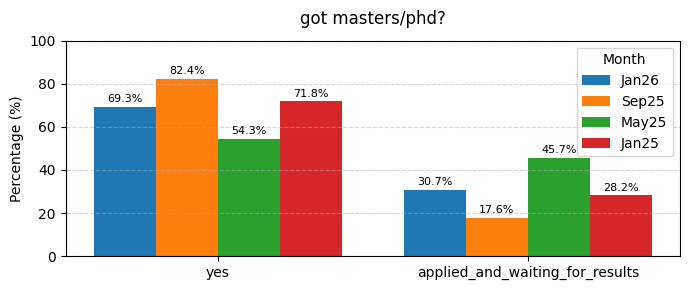

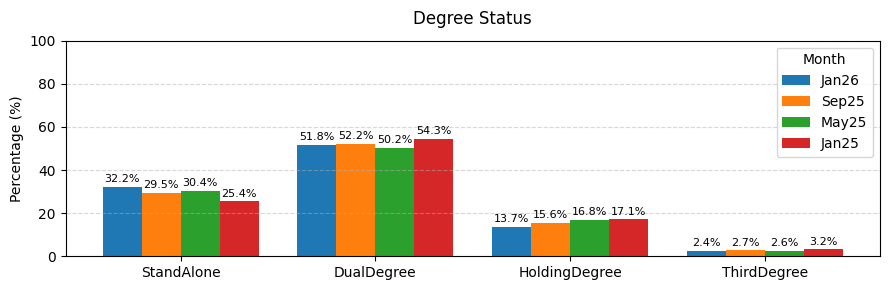

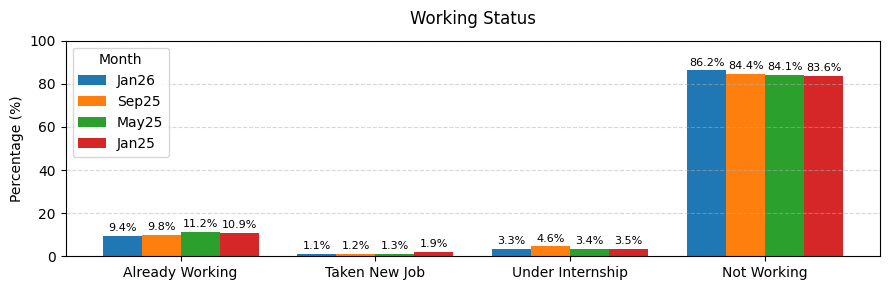

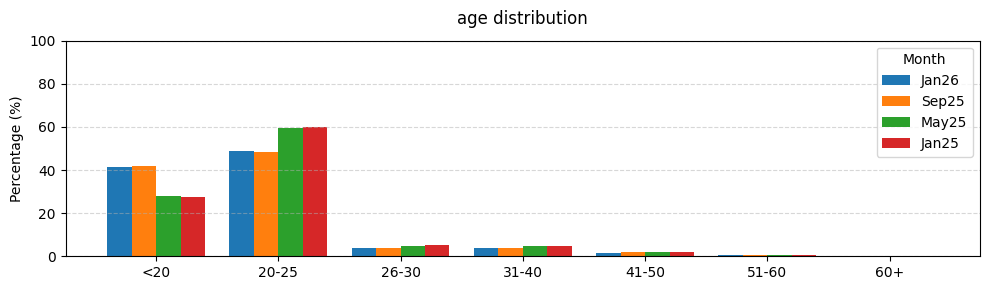

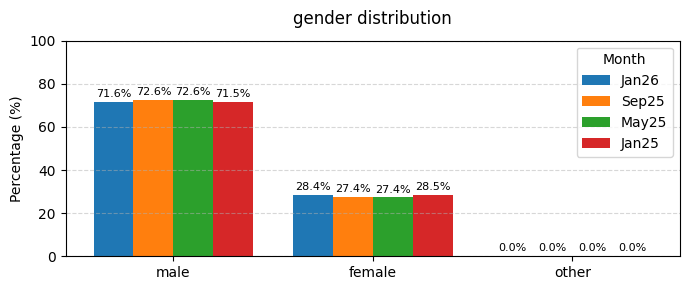

In [ ]:
FIGURES=[]
for table in TABLES_NEEDED:
  df = table_to_df(S3_IN_FILE_NAME, S3_REPORT_SHEET, ws.tables[table])
  df = df.copy()  # safety
  df = df[df[df.columns[0]] != "Total"]
  df = df.set_index(df.columns[0])
  plot_df= df[['%Jan26', '%Sep25', '%May25', '%Jan25']]
  x = np.arange(len(plot_df.index))          # yes, no
  width = 0.2                                # bar width

  if table in FIG_SIZE_DICT:
    fig_size= FIG_SIZE_DICT[table]
  else:
    fig_size= (7,3)
  fig, ax = plt.subplots(figsize=fig_size)

  for i, col in enumerate(plot_df.columns):
      ax.bar(
          x + i * width,
          plot_df[col] * 100,                # convert to %
          width,
          label=col.replace("%", "")
      )
  if table not in BAR_PER_NO:
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", padding=2, fontsize=8)

  # X-axis
  ax.set_xticks(x + width * (len(plot_df.columns) - 1) / 2)
  ax.set_xticklabels(plot_df.index)

  # Y-axis
  ax.set_ylabel("Percentage (%)")
  ax.set_ylim(0, 100)

  ax.set_title(
      TABLE_TITLES[table],
      loc="center",
      pad=12
  )

  # Legend
  ax.legend(title="Month")

  # Grid
  ax.yaxis.grid(True, linestyle="--", alpha=0.5)

  plt.tight_layout()
  plt.show()
  FIGURES.append(fig)

### cgpa buckets

In [ ]:
df = table_to_df(S3_IN_FILE_NAME, S3_REPORT_SHEET, CGPA_LEVEL_TABLE)
df

,cgpa_bucket,BS_DEGREE,DEGREE,DIPLOMA,FOUNDATION
0,<4,0,0,0,1
1,4-5,0,0,11,336
2,5-6,2,4,1290,3029
3,6-7,93,209,4876,5715
4,7-8,207,442,4204,4170
5,8-9,205,308,2138,2078
6,9-10,66,106,640,792
7,Total,573,1069,13159,16121


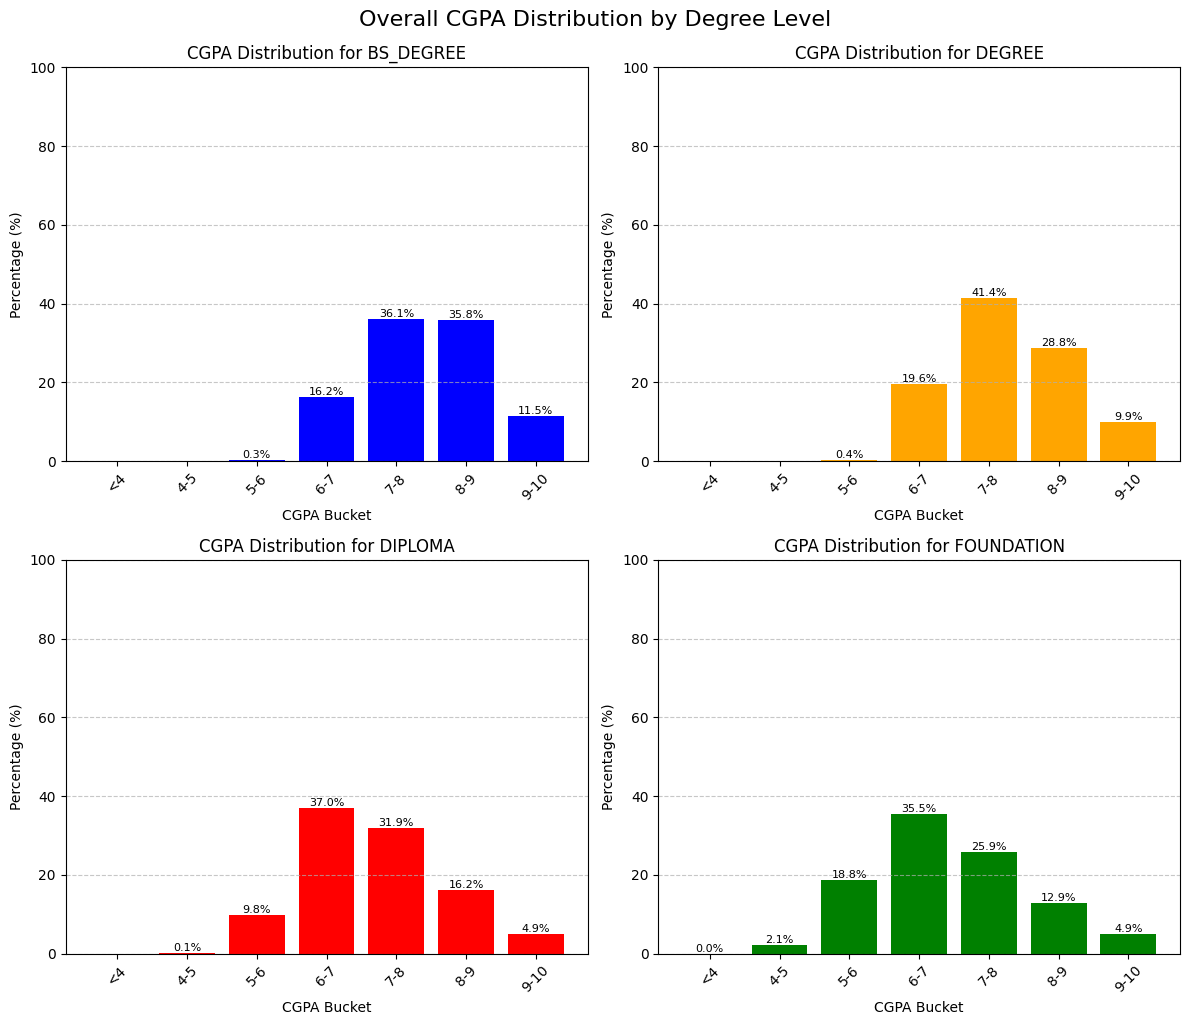

In [ ]:
plot_df = df[df['cgpa_bucket']!= 'Total'].copy()
plot_df = plot_df.set_index('cgpa_bucket')
plot_cols = ['BS_DEGREE', 'DEGREE', 'DIPLOMA', 'FOUNDATION']
colors = ["blue", "orange", "red", "green"]


fig_cgpa, axes = plt.subplots(2, 2, figsize=(12, 10)) # fig_cgpa is the name
axes = axes.flatten()

for i, col_name in enumerate(plot_cols):
    ax = axes[i] # Get the current subplot axis

    total_for_degree = plot_df[col_name].sum()

    if total_for_degree == 0:
        # avoid division by zero
        percentages = pd.Series([0] * len(plot_df.index), index=plot_df.index)
    else:
        percentages = (plot_df[col_name] / total_for_degree * 100).round(2)

    bars = ax.bar(plot_df.index, percentages, color=colors[i])

    # percentage labels on top of bars
    for bar in bars:
        height = bar.get_height()
        if height > 0: # bars that have a value gets the label only
            ax.text(bar.get_x() + bar.get_width() / 2, height,
                    f'{height:.1f}%', ha='center', va='bottom', fontsize=8)


    ax.set_title(f'CGPA Distribution for {col_name}', fontsize=12)
    ax.set_xlabel('CGPA Bucket', fontsize=10)
    ax.set_ylabel('Percentage (%)', fontsize=10)
    ax.set_ylim(0, 100)
    ax.tick_params(axis='x', rotation=45)
    ax.yaxis.grid(True, linestyle='--', alpha=0.7) # grids

plt.tight_layout()
plt.suptitle('Overall CGPA Distribution by Degree Level', y=1.02, fontsize=16)
plt.show()

### master locs

In [ ]:
df = table_to_df(S3_IN_FILE_NAME, S3_REPORT_SHEET, LOCATION_TABLE)
display(df)

,Q5,india,outside_india,not_specified,%india,%outside_india,%not_specified
0,yes,385,73,7,0.97964,0.9359,0.035
1,applied_and_waiting_for_results,8,5,193,0.02036,0.0641,0.965


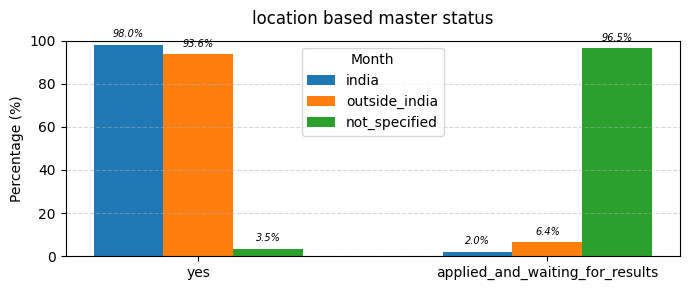

In [ ]:
plot_df = df.set_index(df.columns[0]) # Sets 'Q5' as the index for a new DataFrame
plot_df = plot_df[['%india', '%outside_india', '%not_specified']]
x = np.arange(len(plot_df.index))          # yes, no
width = 0.2                                # bar width

fig_master, ax = plt.subplots(figsize=(7,3))

for i, col in enumerate(plot_df.columns):
    ax.bar(
        x + i * width,
        plot_df[col] * 100,                # convert to %
        width,
        label=col.replace("%", "")
    )

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=4, fontsize=7, fontstyle="oblique")

# X-axis
ax.set_xticks(x + width * (len(plot_df.columns) - 1) / 2)
ax.set_xticklabels(plot_df.index)

# Y-axis as percentage
ax.set_ylabel("Percentage (%)")
ax.set_ylim(0, 100)

# Title
ax.set_title(
    "location based master status",
    loc="center",
    pad=12
)

# Legend
ax.legend(title="Month")

# Grid (optional but improves readability)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## figures

In [ ]:
FIGURES.append(fig_master)
FIGURES.append(fig_cgpa)

In [ ]:
FIGURES

[<Figure size 700x300 with 1 Axes>,
 <Figure size 900x300 with 1 Axes>,
 <Figure size 900x300 with 1 Axes>,
 <Figure size 1000x300 with 1 Axes>,
 <Figure size 700x300 with 1 Axes>,
 <Figure size 700x300 with 1 Axes>,
 <Figure size 1200x1000 with 4 Axes>]

In [ ]:
from io import BytesIO
IMG_BUFFERS=[]
for fig in FIGURES:
  img_buffer= BytesIO()
  fig.savefig(img_buffer, format="png", bbox_inches="tight", dpi=150)
  plt.close(fig)
  img_buffer.seek(0)
  IMG_BUFFERS.append(img_buffer)

In [ ]:
IMG_BUFFERS.__sizeof__()

104

In [ ]:
IMG_BUFFERS

### need

In [ ]:
from openpyxl import Workbook, load_workbook
from openpyxl.drawing.image import Image
from pathlib import Path
from openpyxl.utils import get_column_letter

def save_images_to_excel(
    img_buffers,                 # list[BytesIO]
    xlsx_path="report.xlsx",
    sheet_name="Graphs",
    start_col=1,                 # column A
    start_row=1,                 # row 1
    row_gap=20                   # space between images
):
    # Load or create workbook
    if Path(xlsx_path).exists():
        wb = load_workbook(xlsx_path)
    else:
        wb = Workbook()

    # Load or create sheet
    ws = wb[sheet_name] if sheet_name in wb.sheetnames else wb.create_sheet(sheet_name)

    # Count existing images (to append safely)
    existing_images = len(ws._images)

    # Add images with spacing
    for idx, img_buffer in enumerate(img_buffers):
        img_buffer.seek(0)  # safety reset

        target_row = start_row + (existing_images + idx) * row_gap
        anchor = f"{get_column_letter(start_col)}{target_row}"

        img = Image(img_buffer)
        img.anchor = anchor
        ws.add_image(img)

    # Save workbook
    wb.save(xlsx_path)


In [ ]:
save_images_to_excel(
    img_buffers=IMG_BUFFERS,
    xlsx_path=S3_IN_FILE_NAME,
    sheet_name="Graphs"
)

### if you want to run again make sure to run the bellow as image buffer needs to be created again

In [ ]:
raise ForcefullExeStop

ForcefullExeStop: Dear Executer it's time to download the file and do the editing
                  refer the README.md for details 😄

In [ ]:
from io import BytesIO
import matplotlib.pyplot as plt

# Regenerate img_buffers as they might have been closed by a previous save operation
img_buffers = []
for fig in figures:
  img_buffer = BytesIO()
  fig.savefig(img_buffer, format="png", bbox_inches="tight", dpi=150)
  plt.close(fig)
  img_buffer.seek(0)
  img_buffers.append(img_buffer)

save_images_to_excel(
    img_buffers=img_buffers,
    xlsx_path='graphtry3.xlsx',
    sheet_name="Graphs"
)

### whats plan?
cgpa vs level --> subplots so can't do much
master_loc --> extra table
gender_distribution
master_apply stat
academic stat
working stat
